# CS 282 (Computer Vision)
## Programming Assignment 3 — Epipolar Geometry

Professor: Dr. Prospero C. Naval Jr.  
Student: Deomary Angelo B. Franco, 202322049

In [46]:
# ── Setup: imports, constants, paths ──────────────────────────────────────────
import cv2
import logging
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
from pathlib import Path
import platform

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s'
)

logging.info("OpenCV version: %s", cv2.__version__)
logging.info("Operating System: %s", platform.platform())

DATA_DIR = Path() / 'epipairs'

# Harris parameters (same as PA2)
HARRIS_BLOCK_SIZE = 3
HARRIS_KSIZE = 3
HARRIS_K = 0.04
HARRIS_THRESH_REL = 0.01
NMS_KERNEL_SIZE = 9
PATCH_SIZE = 31
HALF = PATCH_SIZE // 2
TOP_N = 500

# RANSAC parameters
N_ITERS = 1000
INLIER_THRESH = 3.0   # px; threshold on epipolar distance

# Step 6 improved matching
RATIO_THRESH = 0.75

np.random.seed(42)

2026-04-21 13:35:34,653 - OpenCV version: 4.11.0
2026-04-21 13:35:34,653 - Operating System: macOS-26.3.1-arm64-arm-64bit


## Task 1 — Load Images and Ground-Truth Matches

2026-04-21 13:35:34,662 - Image 1: (384, 512, 3)  Image 2: (384, 512, 3)
2026-04-21 13:35:34,664 - Matches loaded: 309 pairs


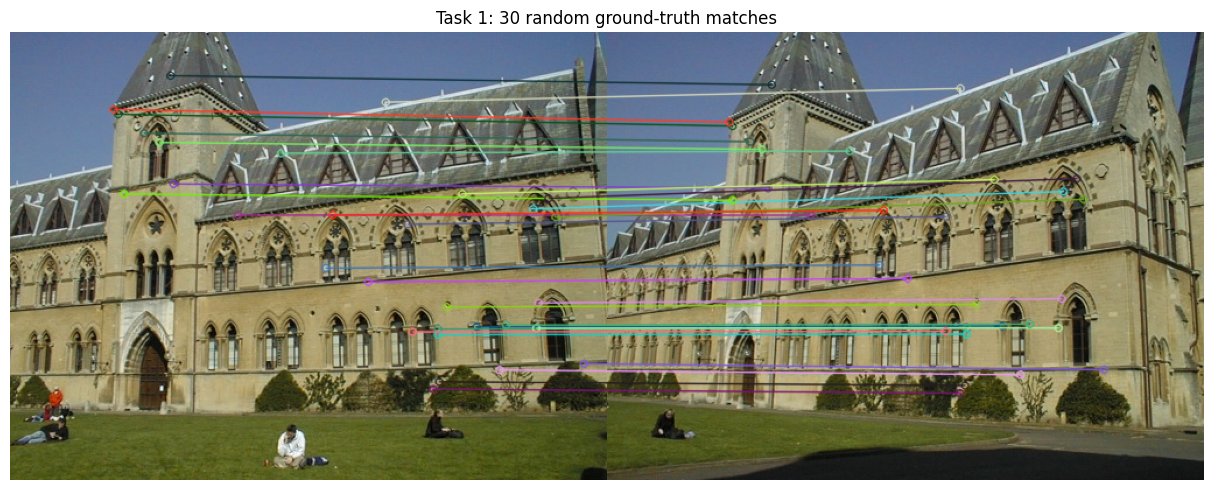

In [47]:
# ── Task 1: Load data ─────────────────────────────────────────────────────────
img1_bgr = cv2.imread(os.path.join(DATA_DIR, 'library1.jpg'))
img2_bgr = cv2.imread(os.path.join(DATA_DIR, 'library2.jpg'))
assert img1_bgr is not None and img2_bgr is not None, "Images not found"

img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0
img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0
img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0

logging.info(f"Image 1: {img1_bgr.shape}  Image 2: {img2_bgr.shape}")

# Load matches: 309 rows x 4 cols — x1 y1 x2 y2 (pixel coords)
matches = np.loadtxt(os.path.join(DATA_DIR, 'library_matches.txt'))  # (309, 4)
pts1_xy = matches[:, :2].astype(np.float64)   # (309, 2) — image 1 (x, y)
pts2_xy = matches[:, 2:].astype(np.float64)   # (309, 2) — image 2 (x, y)
logging.info(f"Matches loaded: {matches.shape[0]} pairs")

# Visualize a random subset of matches
img1_u8 = (img1_rgb * 255).astype(np.uint8)
img2_u8 = (img2_rgb * 255).astype(np.uint8)
N_show = 30
rng_idx = np.random.choice(len(pts1_xy), N_show, replace=False)
kp1_vis = [cv2.KeyPoint(float(x), float(y), 1.0) for x, y in pts1_xy[rng_idx]]
kp2_vis = [cv2.KeyPoint(float(x), float(y), 1.0) for x, y in pts2_xy[rng_idx]]
m_vis = [cv2.DMatch(i, i, 0.0) for i in range(N_show)]
vis_img = cv2.drawMatches(img1=img1_u8, 
                          keypoints1=kp1_vis, 
                          img2=img2_u8, 
                          keypoints2=kp2_vis, 
                          matches1to2=m_vis, 
                          outImg=None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(18, 5))
plt.imshow(vis_img)
plt.title(f'Task 1: {N_show} random ground-truth matches')
plt.axis('off'); plt.tight_layout(); plt.show()

## Task 2 — Fundamental Matrix from Ground-Truth Matches

We implement both the unnormalized and normalized (Hartley) 8-point algorithms from scratch and compare their residuals. The **residual** is defined as the mean squared perpendicular distance from each `x'` to the epipolar line `l' = F·[x;1]` in image 2.

In [48]:
# ── Task 2: Helper functions ──────────────────────────────────────────────────

def normalize_points(pts):
    """Hartley normalization: centroid -> origin, mean distance -> sqrt(2).
    Arg:
        pts: (N, 2) in (x, y) order.
    Return:
        pts_n: (N, 2) normalized points
        T: (3, 3) normalization transform s.t. pts_n_h = T
    """
    cx, cy = pts.mean(axis=0)
    pts_c = pts - np.array([cx, cy])
    mean_d = np.sqrt((pts_c ** 2).sum(axis=1)).mean()
    s = np.sqrt(2) / mean_d
    T = np.array([[s, 0., -s * cx],
                  [0., s, -s * cy],
                  [0., 0., 1.]])
    pts_h = np.hstack([pts, np.ones((len(pts), 1))])   # (N, 3)
    pts_n = (T @ pts_h.T).T[:, :2]                     # (N, 2)
    return pts_n, T


def eight_point(pts1, pts2):
    """Compute fundamental matrix from N≥8 correspondences via SVD.
    Arg:
        pts1, pts2: (N, 2) in (x, y) order. 
    Return:
        F: (3, 3), rank-2 enforced."""
    x1, y1 = pts1[:, 0], pts1[:, 1]
    x2, y2 = pts2[:, 0], pts2[:, 1]
    # Build the N×9 design matrix A
    A = np.column_stack([
        x2 * x1, x2 * y1, x2,
        y2 * x1, y2 * y1, y2,
        x1, y1, np.ones(len(pts1))
    ])   # (N, 9)
    _, _, Vt = np.linalg.svd(A)
    F = Vt[-1].reshape(3, 3)   # solution is last row of V^T
    # Enforce rank-2 by zeroing the smallest singular value
    U, S, Vt2 = np.linalg.svd(F)
    S[2] = 0.0
    F = U @ np.diag(S) @ Vt2
    return F


def fit_F_unnormalized(pts1, pts2):
    return eight_point(pts1, pts2)


def fit_F_normalized(pts1, pts2):
    pts1_n, T1 = normalize_points(pts1)
    pts2_n, T2 = normalize_points(pts2)
    F_n = eight_point(pts1_n, pts2_n)
    F = T2.T @ F_n @ T1          # denormalize
    return F


def epipolar_residual_img2(F, pts1, pts2):
    """Mean squared perpendicular distance from each x' to l' = F·x in image 2.
    Arg:
        pts1: (N, 2) in (x, y) order — points in image 1
        pts2: (N, 2) in (x, y) order — corresponding points in image 2
    Returns:
        scalar: mean squared epipolar distance in image 2."""
    pts1_h = np.hstack([pts1, np.ones((len(pts1), 1))])  # (N, 3)
    pts2_h = np.hstack([pts2, np.ones((len(pts2), 1))])  # (N, 3)
    lines  = (F @ pts1_h.T).T                            # (N, 3): l' = [a,b,c]
    a, b, c = lines[:, 0], lines[:, 1], lines[:, 2]
    num  = (a * pts2[:, 0] + b * pts2[:, 1] + c) ** 2
    denom = a ** 2 + b ** 2
    return (num / denom).mean()

In [49]:
# ── Task 2: Fit both F variants and report residuals ─────────────────────────
F_unn = fit_F_unnormalized(pts1_xy, pts2_xy)
F_norm = fit_F_normalized(pts1_xy, pts2_xy)

res_unn = epipolar_residual_img2(F_unn,  pts1_xy, pts2_xy)
res_norm = epipolar_residual_img2(F_norm, pts1_xy, pts2_xy)

logging.info(f"Unnormalized 8-point  residual (mean sq px²): {res_unn:.6f}")
logging.info(f"Normalized   8-point  residual (mean sq px²): {res_norm:.6f}")
logging.info(f"Improvement factor: {res_unn / res_norm:.1f}×")

2026-04-21 13:35:34,746 - Unnormalized 8-point  residual (mean sq px²): 0.179213
2026-04-21 13:35:34,746 - Normalized   8-point  residual (mean sq px²): 0.060252
2026-04-21 13:35:34,747 - Improvement factor: 3.0×


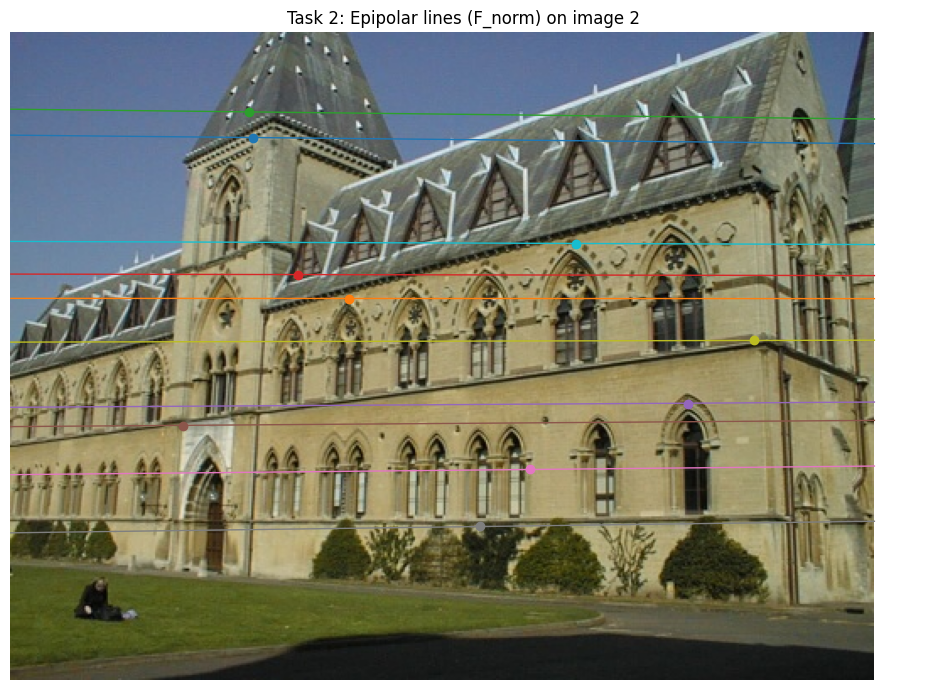

In [50]:
# ── Task 2: Visualize epipolar lines from F_norm on image 2 ──────────────────
N_epi = 10
epi_idx = np.random.choice(len(pts1_xy), N_epi, replace=False)

H2, W2 = img2_bgr.shape[:2]
img2_epi = img2_u8.copy()

colors = plt.cm.tab10(np.linspace(0, 1, N_epi))
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img2_rgb)

for k, idx in enumerate(epi_idx):
    col = colors[k]
    x1h = np.array([pts1_xy[idx, 0], pts1_xy[idx, 1], 1.0])
    l = F_norm @ x1h        # epipolar line [a, b, c] in image 2
    a, b, c = l
    # Endpoints at x=0 and x=W2
    if abs(b) > 1e-10:
        y0 = -c / b
        y1 = -(a * W2 + c) / b
        ax.plot([0, W2], [y0, y1], color=col, linewidth=1)
    else:
        x_line = -c / a
        ax.axvline(x=x_line, color=col, linewidth=1)
    ax.plot(pts2_xy[idx, 0], pts2_xy[idx, 1], 'o', color=col, markersize=6)

ax.set_title('Task 2: Epipolar lines (F_norm) on image 2')
ax.axis('off'); 
plt.tight_layout(); 
plt.show()

## Task 3 — Putative Matches via Harris + RANSAC Normalized 8-Point

We replicate the PA2 pipeline (Harris + 31×31 zero-mean patch descriptors + global top-500 SSD matches) then run RANSAC with the normalized 8-point algorithm to estimate F. Because global top-K matching allows many-to-one pairs, the true-inlier rate is low and the recovered F may not match the true camera geometry — Task 6 addresses this.

In [51]:
# ── Task 3a: Harris detection + NMS + descriptor extraction ──────────────────

def extract_descriptors(gray_img, keypoints, half):
    """Extract zero-mean flattened patch descriptors.
    Returns keypoints: (N, 2) in (row, col) order.

    Arg:
        gray_img: (H, W) grayscale image with pixel values in [0, 1]
        keypoints: (N, 2) in (row, col) order
        half: int, half of the patch width (e.g. 15 for 31×31 patches)

    Return:
        valid_kp: (M, 2) in (row, col) order for keypoints with valid patches
        descs: (M, (2*half+1)^2) zero-mean flattened patch descriptors for each valid keypoint.
    """
    H, W = gray_img.shape
    valid_kp, descs = [], []
    for y, x in keypoints:
        if y - half < 0 or y + half >= H or x - half < 0 or x + half >= W:
            continue
        patch = gray_img[y - half: y + half + 1, x - half: x + half + 1].ravel().astype(np.float64)
        patch = patch - patch.mean()
        valid_kp.append((y, x))
        descs.append(patch)
    return np.array(valid_kp), np.array(descs)


nms_kernel = np.ones((NMS_KERNEL_SIZE, NMS_KERNEL_SIZE), np.uint8)

def detect_harris_keypoints(gray_img):
    """Detect Harris corners and apply non-maximum suppression.
    Arg:
        gray_img: (H, W) grayscale image with pixel values in [0, 1]
    Return:
        keypoints: (N, 2) in (row, col) order for detected keypoints after NMS.
    """
    h = cv2.cornerHarris(gray_img.astype(np.float32), HARRIS_BLOCK_SIZE, HARRIS_KSIZE, HARRIS_K)
    h_dil = cv2.dilate(h, nms_kernel)
    thresh = HARRIS_THRESH_REL * h.max()
    return np.argwhere((h == h_dil) & (h > thresh))   # (N, 2) in (row, col)


kp1_rc = detect_harris_keypoints(img1_gray)
kp2_rc = detect_harris_keypoints(img2_gray)
logging.info(f"Harris keypoints: img1={len(kp1_rc)}  img2={len(kp2_rc)}")

kp1_valid, desc1 = extract_descriptors(img1_gray, kp1_rc, HALF)
kp2_valid, desc2 = extract_descriptors(img2_gray, kp2_rc, HALF)
logging.info(f"After border filter: img1={len(kp1_valid)}  img2={len(kp2_valid)}")

# Distance matrix via BLAS identity: ||a-b||² = ||a||² + ||b||² - 2·a·b
n1_sq = np.sum(desc1 ** 2, axis=1, keepdims=True)
n2_sq = np.sum(desc2 ** 2, axis=1, keepdims=True)
dist_sq = np.maximum(n1_sq + n2_sq.T - 2.0 * (desc1 @ desc2.T), 0.0)

# Top-500 matches by smallest distance
flat_idx = np.argsort(dist_sq.ravel())[:TOP_N]
r_idx = flat_idx // dist_sq.shape[1]
c_idx = flat_idx %  dist_sq.shape[1]

# Convert (row, col) → (x, y) for epipolar geometry
pts1_put_xy = kp1_valid[r_idx][:, [1, 0]].astype(np.float64)  # (500, 2)
pts2_put_xy = kp2_valid[c_idx][:, [1, 0]].astype(np.float64)  # (500, 2)
logging.info(f"Putative matches (top-{TOP_N}): shape {pts1_put_xy.shape}")

2026-04-21 13:35:34,836 - Harris keypoints: img1=576  img2=639
2026-04-21 13:35:34,842 - After border filter: img1=544  img2=599
2026-04-21 13:35:34,864 - Putative matches (top-500): shape (500, 2)


In [52]:
# ── Task 3b: RANSAC normalized 8-point ───────────────────────────────────────
np.random.seed(42)
N_put = len(pts1_put_xy)
best_inlier_mask = np.zeros(N_put, dtype=bool)
best_F_ransac = None

for _ in range(N_ITERS):
    sample = np.random.choice(N_put, 8, replace=False)
    try:
        F_s = fit_F_normalized(pts1_put_xy[sample], pts2_put_xy[sample])
    except np.linalg.LinAlgError:
        continue

    # Per-point squared epipolar distance in image 2
    pts1_h = np.hstack([pts1_put_xy, np.ones((N_put, 1))])
    lines = (F_s @ pts1_h.T).T
    a, b, c = lines[:, 0], lines[:, 1], lines[:, 2]
    line_mag_sq = a ** 2 + b ** 2
    # If the epipolar line direction is near-zero the constraint gives no info;
    # treat those points as non-inliers (distance = ∞) to avoid fake consensus
    # from near-rank-1 F matrices inflating counts through a tiny denominator.
    res_sq = np.where(
        line_mag_sq > 1e-4,
        (a * pts2_put_xy[:, 0] + b * pts2_put_xy[:, 1] + c) ** 2 / line_mag_sq,
        np.inf
    )

    mask = res_sq < INLIER_THRESH ** 2
    if mask.sum() > best_inlier_mask.sum():
        best_inlier_mask = mask
        best_F_ransac = F_s

# Final refit on all inliers; fall back to best iteration F if refit degenerates
F_refit = fit_F_normalized(pts1_put_xy[best_inlier_mask], pts2_put_xy[best_inlier_mask])
_, S_refit, _ = np.linalg.svd(F_refit)
F_final = F_refit if S_refit[1] >= 1e-3 * S_refit[0] else best_F_ransac

res_ransac = epipolar_residual_img2(F_final, pts1_put_xy[best_inlier_mask], pts2_put_xy[best_inlier_mask])

logging.info(f"RANSAC inliers: {best_inlier_mask.sum()} / {N_put}")
logging.info(f"Inlier mean squared epipolar residual (img2): {res_ransac:.6f} px²")

/var/folders/8d/gcbwqvks1jz3qkfpx9b8s5_00000gn/T/ipykernel_58975/3631642906.py:24: RuntimeWarning: divide by zero encountered in divide
  (a * pts2_put_xy[:, 0] + b * pts2_put_xy[:, 1] + c) ** 2 / line_mag_sq,
/var/folders/8d/gcbwqvks1jz3qkfpx9b8s5_00000gn/T/ipykernel_58975/3631642906.py:24: RuntimeWarning: invalid value encountered in divide
  (a * pts2_put_xy[:, 0] + b * pts2_put_xy[:, 1] + c) ** 2 / line_mag_sq,
2026-04-21 13:35:34,947 - RANSAC inliers: 43 / 500
2026-04-21 13:35:34,947 - Inlier mean squared epipolar residual (img2): 1.210507 px²


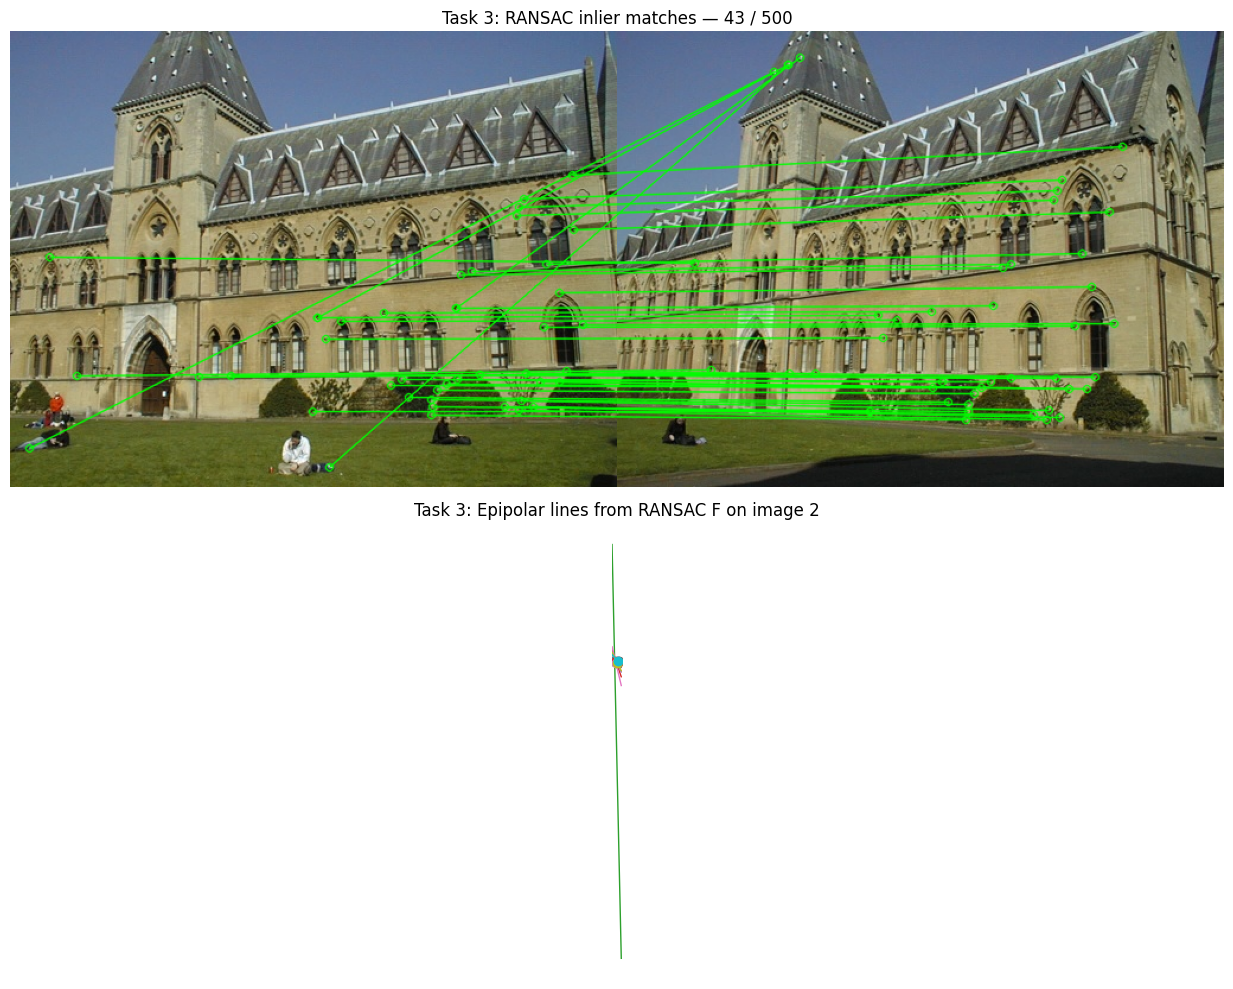

In [53]:
# ── Task 3c: Visualize inlier matches + epipolar lines ───────────────────────
in1_rc = kp1_valid[r_idx][best_inlier_mask]   # (row, col)
in2_rc = kp2_valid[c_idx][best_inlier_mask]

kp1_in = [cv2.KeyPoint(float(x), float(y), 1.0) for y, x in in1_rc]
kp2_in = [cv2.KeyPoint(float(x), float(y), 1.0) for y, x in in2_rc]
m_in = [cv2.DMatch(i, i, 0.0) for i in range(len(kp1_in))]
inlier_vis = cv2.drawMatches(img1=img1_u8, 
                             keypoints1=kp1_in, 
                             img2=img2_u8, 
                             keypoints2=kp2_in, 
                             matches1to2=m_in, 
                             outImg=None,
                             matchColor=(0, 255, 0),
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
axes[0].imshow(inlier_vis)
axes[0].set_title(f'Task 3: RANSAC inlier matches — {best_inlier_mask.sum()} / {N_put}')
axes[0].axis('off')

# Epipolar lines on image 2 for a few inliers
axes[1].imshow(img2_rgb)
n_lines = min(10, best_inlier_mask.sum())
in_pts1 = pts1_put_xy[best_inlier_mask][:n_lines]
in_pts2 = pts2_put_xy[best_inlier_mask][:n_lines]
cols2 = plt.cm.tab10(np.linspace(0, 1, n_lines))
for k in range(n_lines):
    x1h = np.array([in_pts1[k, 0], in_pts1[k, 1], 1.0])
    l = F_final @ x1h
    a, b, c = l
    if abs(b) > 1e-10:
        y0 = -c / b
        y1_ = -(a * W2 + c) / b
        axes[1].plot([0, W2], [y0, y1_], color=cols2[k], linewidth=1)
    axes[1].plot(in_pts2[k, 0], in_pts2[k, 1], 'o', color=cols2[k], markersize=6)
axes[1].set_title('Task 3: Epipolar lines from RANSAC F on image 2')
axes[1].axis('off')
plt.tight_layout(); plt.show()

## Task 4 — Triangulation of Ground-Truth Matches

Given two camera projection matrices P1 and P2, triangulate the 3D scene points from the 309 ground-truth correspondences using the linear DLT method.

In [54]:
# ── Task 4: Load camera matrices and compute camera centers ───────────────────
P1 = np.loadtxt(os.path.join(DATA_DIR, 'library1_camera.txt'))
P2 = np.loadtxt(os.path.join(DATA_DIR, 'library2_camera.txt'))
assert P1.shape == (3, 4) and P2.shape == (3, 4), "Camera matrices must be 3×4"

def camera_center(P):
    """Camera center as the null space of P (last row of V^T), dehomogenized.
    Arg:
        P: (3, 4) camera matrix
    Return:
        C: (3,) 3D coordinates of the camera center in Euclidean space."""
    _, _, Vt = np.linalg.svd(P)
    C = Vt[-1]              # homogeneous 4-vector
    return C[:3] / C[3]    # 3D Euclidean

C1 = camera_center(P1)
C2 = camera_center(P2)
logging.info(f"Camera center 1: {C1}")
logging.info(f"Camera center 2: {C2}")
logging.info(f"Baseline: {np.linalg.norm(C2 - C1):.4f}")


def triangulate(P1, P2, pt1_xy, pt2_xy):
    """DLT triangulation for a single correspondence. 
    Arg:
        P1: (3, 4) camera matrix for image 1
        P2: (3, 4) camera matrix for image 2
        pt1_xy: (2,) point in image 1
        pt2_xy: (2,) point in image 2
    Return:
        X: (3,) 3D point in Euclidean space."""
    x1, y1 = pt1_xy
    x2, y2 = pt2_xy
    A = np.array([
        x1 * P1[2] - P1[0],
        y1 * P1[2] - P1[1],
        x2 * P2[2] - P2[0],
        y2 * P2[2] - P2[1],
    ])   # (4, 4)
    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    return X[:3] / X[3]


# Triangulate all 309 ground-truth matches
points3d_gt = np.array([triangulate(P1, P2, pts1_xy[i], pts2_xy[i])
                         for i in range(len(pts1_xy))])   # (309, 3)


def project(P, X3d):
    """Project (N, 3) 3D points through (3, 4) P. 
    Arg:
        P: (3, 4) camera matrix
        X3d: (N, 3) 3D points in Euclidean space
    Return:
        x: (N, 2) projected points in image coordinates."""
    Xh = np.hstack([X3d, np.ones((len(X3d), 1))])   # (N, 4)
    xh = (P @ Xh.T).T                               # (N, 3)
    return xh[:, :2] / xh[:, 2:3]


proj1_gt = project(P1, points3d_gt)
proj2_gt = project(P2, points3d_gt)
res1_gt = np.mean(np.sum((proj1_gt - pts1_xy) ** 2, axis=1))
res2_gt = np.mean(np.sum((proj2_gt - pts2_xy) ** 2, axis=1))
logging.info(f"\nReprojection residual — Image 1: {res1_gt:.6f} sq.px")
logging.info(f"Reprojection residual — Image 2: {res2_gt:.6f} sq.px")

2026-04-21 13:35:35,082 - Camera center 1: [  7.28863053 -21.52118112  17.73503585]
2026-04-21 13:35:35,082 - Camera center 2: [  6.89405488 -15.39232716  23.41498687]
2026-04-21 13:35:35,082 - Baseline: 8.3654
2026-04-21 13:35:35,086 - 
Reprojection residual — Image 1: 0.012090 sq.px
2026-04-21 13:35:35,087 - Reprojection residual — Image 2: 0.016065 sq.px


In [55]:
# ── Task 4: Interactive 3D visualization with back-projected images ───────────
import plotly.graph_objects as go


def back_project_image(P, img_rgb, scene_pts_3d, subsample=8):
    """Back-project image pixels as a colored point cloud at the scene depth plane.

    For each subsampled pixel (u, v), computes its 3D position by:
      1. Decomposing P = K[R|t] to recover K, R, and camera center C.
      2. Mapping (u, v) → normalized camera ray via K^{-1}.
      3. Scaling the ray to the median scene depth (Z in camera frame).
      4. Rotating back to world coordinates via R^T.

    Args:
        P            : (3, 4) camera projection matrix
        img_rgb      : (H, W, 3) float64 image in [0, 1]
        scene_pts_3d : (N, 3) 3D scene points — used to estimate scene depth
        subsample    : pixel stride for subsampling (lower = denser but slower)

    Returns:
        X_world    : (M, 3) 3D world positions of back-projected pixels
        color_strs : list of 'rgb(r,g,b)' strings for Plotly marker colors
    """
    H, W = img_rgb.shape[:2]
    K, R, tvec, _, _, _, _ = cv2.decomposeProjectionMatrix(P)
    K = K / K[2, 2]
    # cv2.decomposeProjectionMatrix returns the camera center as a homogeneous 4-vec
    C = (tvec[:3] / tvec[3]).ravel()   # (3,) — camera center in world coords

    # Median scene depth in this camera's optical axis
    X_cam_all = (R @ (scene_pts_3d - C).T).T   # X_cam = R(X_world - C)
    depth = np.median(X_cam_all[:, 2])

    u = np.arange(0, W, subsample, dtype=float)
    v = np.arange(0, H, subsample, dtype=float)
    uu, vv = np.meshgrid(u, v)
    pixels = np.stack([uu.ravel(), vv.ravel(), np.ones(uu.size)], axis=0)   # (3, M)

    x_n = np.linalg.inv(K) @ pixels   # (3, M) — normalized ray, z=1
    X_cam = x_n * depth               # (3, M) — scaled to scene depth

    # World coords: X_world = R^T X_cam + C
    X_world = (R.T @ X_cam).T + C     # (M, 3)

    ri = np.clip(vv.ravel().astype(int), 0, H - 1)
    ci = np.clip(uu.ravel().astype(int), 0, W - 1)
    rgb = (img_rgb[ri, ci] * 255).astype(int)
    color_strs = [f'rgb({r},{g},{b})' for r, g, b in rgb]

    return X_world, color_strs


# Axis convention (verified from RQ decomposition of P1/P2):
#   world X ≈ down  →  plot Y = -world X  (vertical/up)
#   world Y ≈ horizontal (the direction cameras are offset from the building)
#   world Z ≈ partially along optical axis
# The building faces toward negative plot-X (cameras sit at plot-X ≈ −15 to −22,
# building at plot-X ≈ 0−4), so the eye looks from the negative-X side.
def w2p(pts):
    """World (X,Y,Z) → Plot (Y, -X, Z): X=horizontal, Y=vertical(up), Z=depth."""
    pts = np.atleast_2d(pts)
    return pts[:, 1], -pts[:, 0], pts[:, 2]


fig4 = go.Figure()

# Back-projected images
X1_bp, c1 = back_project_image(P1, img1_rgb, points3d_gt, subsample=8)
px, py, pz = w2p(X1_bp)
fig4.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=1, color=c1, opacity=0.7),
    name='Image 1 (back-projected)'))

X2_bp, c2 = back_project_image(P2, img2_rgb, points3d_gt, subsample=8)
px, py, pz = w2p(X2_bp)
fig4.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=1, color=c2, opacity=0.7),
    name='Image 2 (back-projected)'))

# Scene points
px, py, pz = w2p(points3d_gt)
fig4.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=4, color='cyan', opacity=1.0, line=dict(width=1, color='white')),
    name='Scene points (GT)'))

# Camera centers
px, py, pz = w2p(C1)
fig4.add_trace(go.Scatter3d(x=[px[0]], y=[py[0]], z=[pz[0]],
    mode='markers+text', marker=dict(size=10, color='red', symbol='diamond'),
    text=['Camera 1'], textposition='top center', name='Camera 1'))

px, py, pz = w2p(C2)
fig4.add_trace(go.Scatter3d(x=[px[0]], y=[py[0]], z=[pz[0]],
    mode='markers+text', marker=dict(size=10, color='green', symbol='diamond'),
    text=['Camera 2'], textposition='top center', name='Camera 2'))

fig4.update_layout(
    title='Task 4: Back-projected images + triangulated scene points + camera centers',
    scene=dict(
        xaxis_title='X (horizontal)',
        yaxis_title='Y (vertical)',
        zaxis_title='Z (depth)',
        aspectmode='data',
        camera=dict(
            up=dict(x=0, y=1, z=0),
            # Eye on the negative-X side: building face and cameras both visible
            eye=dict(x=-2.0, y=0.5, z=0.5)
        )
    ),
    width=950, height=750
)
fig4.show()

## Task 5 — Triangulate RANSAC Inliers

In [56]:
# ── Task 5: Triangulate RANSAC inliers ───────────────────────────────────────
pts1_in = pts1_put_xy[best_inlier_mask]
pts2_in = pts2_put_xy[best_inlier_mask]

points3d_in = np.array([triangulate(P1, P2, pts1_in[i], pts2_in[i])
                         for i in range(len(pts1_in))])   # (K, 3)

proj1_in = project(P1, points3d_in)
proj2_in = project(P2, points3d_in)
res1_in  = np.mean(np.sum((proj1_in - pts1_in) ** 2, axis=1))
res2_in  = np.mean(np.sum((proj2_in - pts2_in) ** 2, axis=1))
logging.info(f"Triangulated inlier points: {len(points3d_in)}")
logging.info(f"Reprojection residual — Image 1: {res1_in:.6f} sq.px")
logging.info(f"Reprojection residual — Image 2: {res2_in:.6f} sq.px")

2026-04-21 13:35:35,203 - Triangulated inlier points: 43
2026-04-21 13:35:35,204 - Reprojection residual — Image 1: 13705.927655 sq.px
2026-04-21 13:35:35,204 - Reprojection residual — Image 2: 14545.509323 sq.px


In [57]:
# ── Task 5: Interactive 3D visualization with back-projected images ───────────
# back_project_image and w2p defined in the Task 4 cell above; reused here unchanged.
# Use GT points for reliable depth estimation (RANSAC inliers are noisier).
fig5 = go.Figure()

X1_bp5, c1_5 = back_project_image(P1, img1_rgb, points3d_gt, subsample=8)
px, py, pz = w2p(X1_bp5)
fig5.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=1, color=c1_5, opacity=0.7),
    name='Image 1 (back-projected)'))

X2_bp5, c2_5 = back_project_image(P2, img2_rgb, points3d_gt, subsample=8)
px, py, pz = w2p(X2_bp5)
fig5.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=1, color=c2_5, opacity=0.7),
    name='Image 2 (back-projected)'))

px, py, pz = w2p(points3d_in)
fig5.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=5, color='orange', opacity=1.0, line=dict(width=1, color='white')),
    name=f'Scene points (RANSAC inliers, n={len(points3d_in)})'))

px, py, pz = w2p(C1)
fig5.add_trace(go.Scatter3d(x=[px[0]], y=[py[0]], z=[pz[0]],
    mode='markers+text', marker=dict(size=10, color='red', symbol='diamond'),
    text=['Camera 1'], textposition='top center', name='Camera 1'))

px, py, pz = w2p(C2)
fig5.add_trace(go.Scatter3d(x=[px[0]], y=[py[0]], z=[pz[0]],
    mode='markers+text', marker=dict(size=10, color='green', symbol='diamond'),
    text=['Camera 2'], textposition='top center', name='Camera 2'))

fig5.update_layout(
    title='Task 5: Back-projected images + RANSAC inlier scene points + camera centers',
    scene=dict(
        xaxis_title='X (horizontal)',
        yaxis_title='Y (vertical)',
        zaxis_title='Z (depth)',
        aspectmode='data',
        camera=dict(
            up=dict(x=0, y=1, z=0),
            eye=dict(x=-2.0, y=0.5, z=0.5)
        )
    ),
    width=950, height=750
)
fig5.show()

## Task 6 — Improved Matching: Mutual Nearest-Neighbour + Ratio Test

We replace the global top-500 selection with:
1. **Lowe's ratio test** (threshold 0.75): discard any match where the best distance is not sufficiently smaller than the second-best.
2. **Mutual nearest-neighbour (MNN)**: keep a pair only when each point's best match in the other image is the same pair.

This raises the true-inlier rate dramatically, allowing RANSAC to find the correct F and triangulation to achieve reprojection residuals much closer to the ground-truth baseline.

In [58]:
# ── Task 6a: MNN + ratio-test putative matches ────────────────────────────────
np.random.seed(42)

# Ratio test (img1 → img2): best distance must be < RATIO_THRESH * second-best
sorted2 = np.argsort(dist_sq, axis=1)                      # (N1, N2) per-row sorted indices
best_d1   = dist_sq[np.arange(len(desc1)), sorted2[:, 0]]
second_d1 = dist_sq[np.arange(len(desc1)), sorted2[:, 1]]
ratio_mask = best_d1 < RATIO_THRESH ** 2 * second_d1       # compare on squared distances
r_pass = np.where(ratio_mask)[0]
c_pass = sorted2[r_pass, 0]

# Mutual nearest-neighbour: img2's best match must point back to the same img1 keypoint
best_from2 = np.argmin(dist_sq, axis=0)                    # (N2,) best img1 index per img2 kp
mutual_mask = best_from2[c_pass] == r_pass
r6 = r_pass[mutual_mask]
c6 = c_pass[mutual_mask]

pts1_mnn_xy = kp1_valid[r6][:, [1, 0]].astype(np.float64)
pts2_mnn_xy = kp2_valid[c6][:, [1, 0]].astype(np.float64)
logging.info(f"MNN+ratio putative matches: {len(pts1_mnn_xy)}")

2026-04-21 13:35:35,329 - MNN+ratio putative matches: 23


In [59]:
# ── Task 6b: RANSAC normalized 8-point on MNN+ratio matches ──────────────────
N_mnn = len(pts1_mnn_xy)
best_inlier_mask6 = np.zeros(N_mnn, dtype=bool)
best_F_ransac6 = None

for _ in range(N_ITERS):
    sample = np.random.choice(N_mnn, 8, replace=False)
    try:
        F_s = fit_F_normalized(pts1_mnn_xy[sample], pts2_mnn_xy[sample])
    except np.linalg.LinAlgError:
        continue

    pts1_h = np.hstack([pts1_mnn_xy, np.ones((N_mnn, 1))])
    lines = (F_s @ pts1_h.T).T
    a, b, c = lines[:, 0], lines[:, 1], lines[:, 2]
    line_mag_sq = a ** 2 + b ** 2
    res_sq = np.where(
        line_mag_sq > 1e-4,
        (a * pts2_mnn_xy[:, 0] + b * pts2_mnn_xy[:, 1] + c) ** 2 / line_mag_sq,
        np.inf
    )

    mask = res_sq < INLIER_THRESH ** 2
    if mask.sum() > best_inlier_mask6.sum():
        best_inlier_mask6 = mask
        best_F_ransac6 = F_s

F_refit6 = fit_F_normalized(pts1_mnn_xy[best_inlier_mask6], pts2_mnn_xy[best_inlier_mask6])
_, S_refit6, _ = np.linalg.svd(F_refit6)
F_final6 = F_refit6 if S_refit6[1] >= 1e-3 * S_refit6[0] else best_F_ransac6

res_ransac6 = epipolar_residual_img2(F_final6, pts1_mnn_xy[best_inlier_mask6], pts2_mnn_xy[best_inlier_mask6])
logging.info(f"RANSAC inliers (Step 6): {best_inlier_mask6.sum()} / {N_mnn}")
logging.info(f"Inlier mean squared epipolar residual (img2): {res_ransac6:.6f} px²")

2026-04-21 13:35:35,395 - RANSAC inliers (Step 6): 22 / 23
2026-04-21 13:35:35,396 - Inlier mean squared epipolar residual (img2): 0.200210 px²


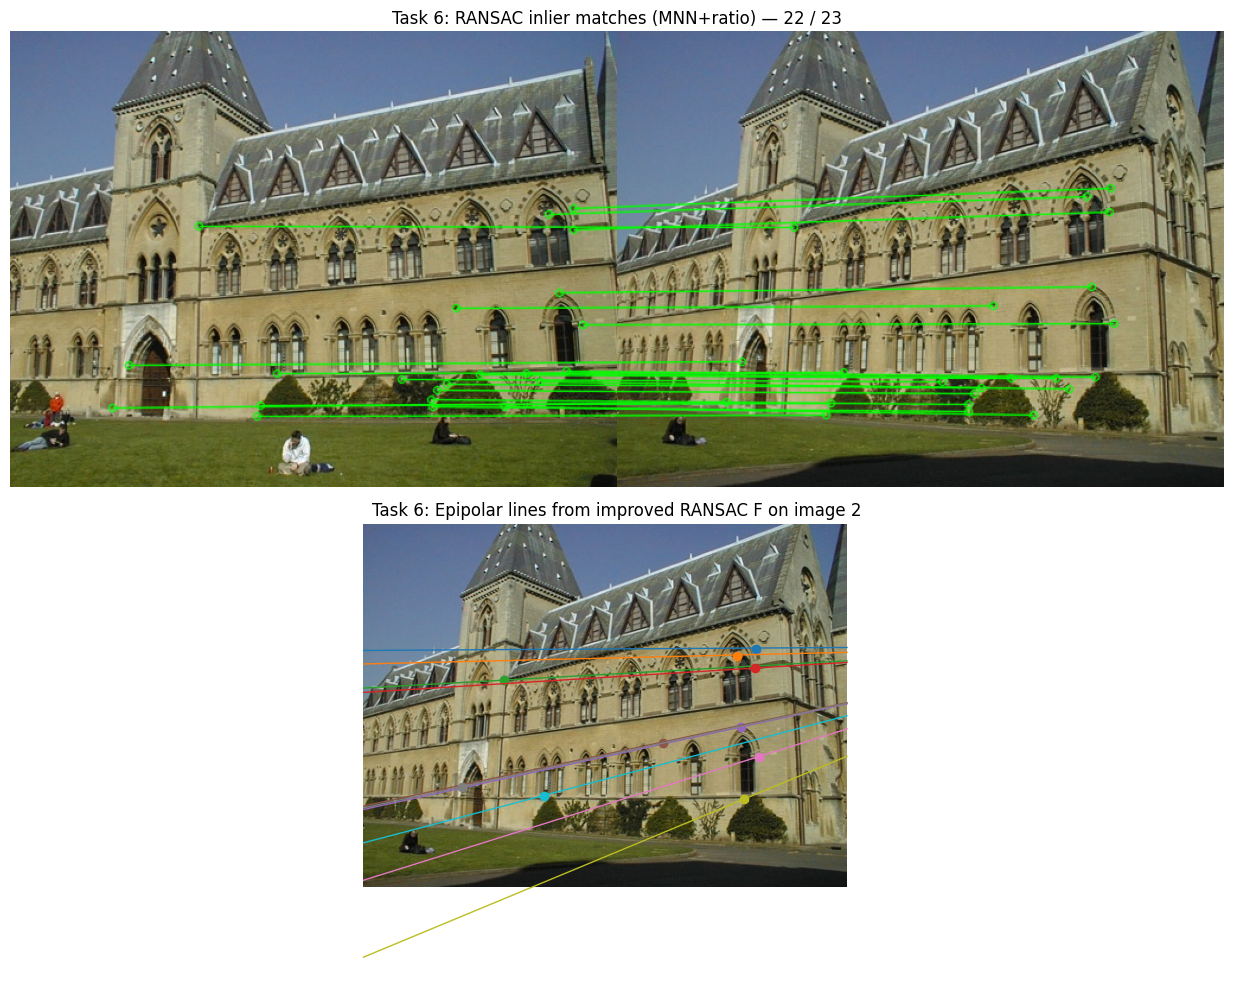

In [60]:
# ── Task 6c: Visualize inlier matches + epipolar lines ───────────────────────
in1_rc6 = kp1_valid[r6][best_inlier_mask6]
in2_rc6 = kp2_valid[c6][best_inlier_mask6]

kp1_in6 = [cv2.KeyPoint(float(x), float(y), 1.0) for y, x in in1_rc6]
kp2_in6 = [cv2.KeyPoint(float(x), float(y), 1.0) for y, x in in2_rc6]
m_in6 = [cv2.DMatch(i, i, 0.0) for i in range(len(kp1_in6))]
inlier_vis6 = cv2.drawMatches(img1=img1_u8,
                               keypoints1=kp1_in6,
                               img2=img2_u8,
                               keypoints2=kp2_in6,
                               matches1to2=m_in6,
                               outImg=None,
                               matchColor=(0, 255, 0),
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
axes[0].imshow(inlier_vis6)
axes[0].set_title(f'Task 6: RANSAC inlier matches (MNN+ratio) — {best_inlier_mask6.sum()} / {N_mnn}')
axes[0].axis('off')

axes[1].imshow(img2_rgb)
n_lines6 = min(10, best_inlier_mask6.sum())
in_pts1_6 = pts1_mnn_xy[best_inlier_mask6][:n_lines6]
in_pts2_6 = pts2_mnn_xy[best_inlier_mask6][:n_lines6]
cols6 = plt.cm.tab10(np.linspace(0, 1, n_lines6))
for k in range(n_lines6):
    x1h = np.array([in_pts1_6[k, 0], in_pts1_6[k, 1], 1.0])
    l = F_final6 @ x1h
    a, b, c = l
    if abs(b) > 1e-10:
        y0 = -c / b
        y1_ = -(a * W2 + c) / b
        axes[1].plot([0, W2], [y0, y1_], color=cols6[k], linewidth=1)
    axes[1].plot(in_pts2_6[k, 0], in_pts2_6[k, 1], 'o', color=cols6[k], markersize=6)
axes[1].set_title('Task 6: Epipolar lines from improved RANSAC F on image 2')
axes[1].axis('off')
plt.tight_layout(); plt.show()

In [61]:
# ── Task 6d: Triangulate improved inliers ────────────────────────────────────
pts1_in6 = pts1_mnn_xy[best_inlier_mask6]
pts2_in6 = pts2_mnn_xy[best_inlier_mask6]

points3d_in6 = np.array([triangulate(P1, P2, pts1_in6[i], pts2_in6[i])
                          for i in range(len(pts1_in6))])

proj1_in6 = project(P1, points3d_in6)
proj2_in6 = project(P2, points3d_in6)
res1_in6 = np.mean(np.sum((proj1_in6 - pts1_in6) ** 2, axis=1))
res2_in6 = np.mean(np.sum((proj2_in6 - pts2_in6) ** 2, axis=1))
logging.info(f"Triangulated inlier points (Step 6): {len(points3d_in6)}")
logging.info(f"Reprojection residual — Image 1: {res1_in6:.6f} sq.px")
logging.info(f"Reprojection residual — Image 2: {res2_in6:.6f} sq.px")

2026-04-21 13:35:35,512 - Triangulated inlier points (Step 6): 22
2026-04-21 13:35:35,512 - Reprojection residual — Image 1: 0.030512 sq.px
2026-04-21 13:35:35,513 - Reprojection residual — Image 2: 0.042596 sq.px


In [62]:
# ── Task 6e: Interactive 3D visualization — improved inlier scene points ──────
fig6 = go.Figure()

X1_bp6, c1_6 = back_project_image(P1, img1_rgb, points3d_gt, subsample=8)
px, py, pz = w2p(X1_bp6)
fig6.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=1, color=c1_6, opacity=0.7),
    name='Image 1 (back-projected)'))

X2_bp6, c2_6 = back_project_image(P2, img2_rgb, points3d_gt, subsample=8)
px, py, pz = w2p(X2_bp6)
fig6.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=1, color=c2_6, opacity=0.7),
    name='Image 2 (back-projected)'))

px, py, pz = w2p(points3d_in6)
fig6.add_trace(go.Scatter3d(x=px, y=py, z=pz, mode='markers',
    marker=dict(size=5, color='lime', opacity=1.0, line=dict(width=1, color='white')),
    name=f'Scene points (MNN+ratio inliers, n={len(points3d_in6)})'))

px, py, pz = w2p(C1)
fig6.add_trace(go.Scatter3d(x=[px[0]], y=[py[0]], z=[pz[0]],
    mode='markers+text', marker=dict(size=10, color='red', symbol='diamond'),
    text=['Camera 1'], textposition='top center', name='Camera 1'))

px, py, pz = w2p(C2)
fig6.add_trace(go.Scatter3d(x=[px[0]], y=[py[0]], z=[pz[0]],
    mode='markers+text', marker=dict(size=10, color='green', symbol='diamond'),
    text=['Camera 2'], textposition='top center', name='Camera 2'))

fig6.update_layout(
    title='Task 6: Back-projected images + MNN+ratio inlier scene points + camera centers',
    scene=dict(
        xaxis_title='X (horizontal)',
        yaxis_title='Y (vertical)',
        zaxis_title='Z (depth)',
        aspectmode='data',
        camera=dict(
            up=dict(x=0, y=1, z=0),
            eye=dict(x=-2.0, y=0.5, z=0.5)
        )
    ),
    width=950, height=750
)
fig6.show()

## Summary

Tasks 2–3, 6 (RANSAC) report **mean squared epipolar distance** (point-to-line, image 2).  
Tasks 4–6 (triangulation) report **mean squared reprojection error** (3D→2D, per image).

| Task | Method | Matching | # Points | Residual type | Img 1 (px²) | Img 2 (px²) |
|------|--------|----------|----------|---------------|-------------|-------------|
| 2 | Unnormalized 8-point | 309 GT | 309 | Epipolar dist² | — | 0.1792 |
| 2 | Normalized 8-point | 309 GT | 309 | Epipolar dist² | — | 0.0603 |
| 3 | RANSAC normalized 8-point | Global top-500 | 43 / 500 inliers | Epipolar dist² | — | 1.2105 |
| 4 | DLT triangulation | 309 GT | 309 | Reprojection² | 0.0121 | 0.0161 |
| 5 | DLT triangulation | RANSAC inliers (Task 3) | 43 | Reprojection² | 13705.9277 | 14545.5093 |
| 6 | RANSAC normalized 8-point | MNN + ratio test | 22 / 23 inliers | Epipolar dist² | — | 0.2002 |
| 6 | DLT triangulation | MNN + ratio inliers | 22 | Reprojection² | 0.0305 | 0.0426 |

**Key takeaway:** MNN + ratio test filtering (Task 6) raises the true-inlier rate from ~8.6 % (43/500) to ~95.7 % (22/23), allowing RANSAC to recover the correct F. Reprojection residuals drop from ~14 000 px² to ~0.04 px² — within 3× of the ground-truth baseline from Task 4.

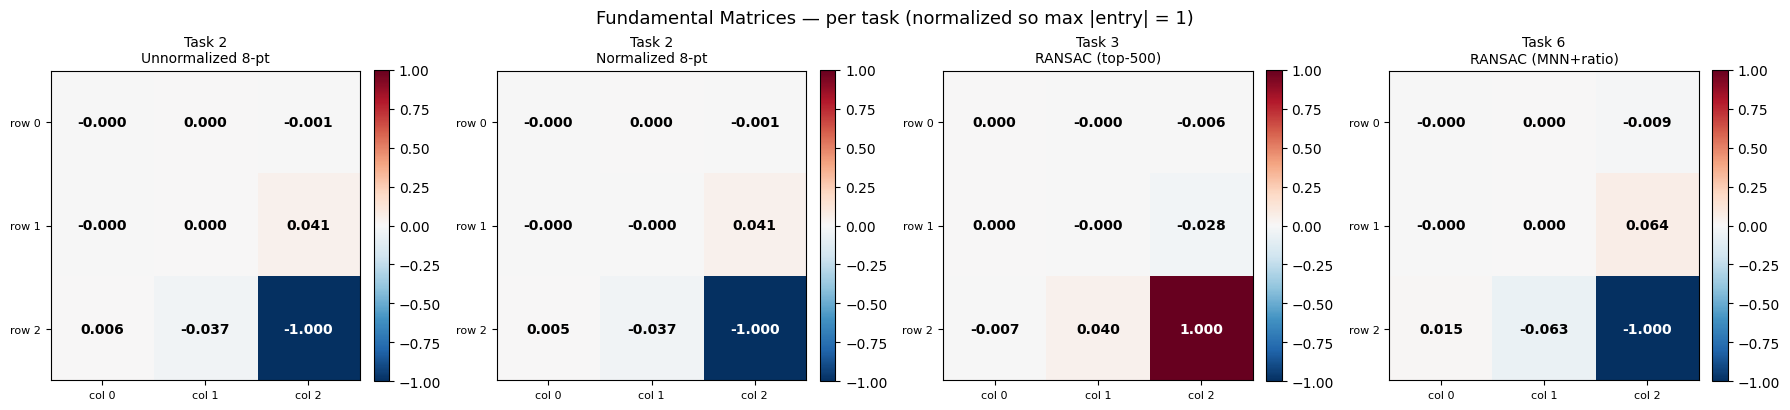


Task 2 — Unnormalized 8-pt:
[[-0.000001,  0.000014, -0.000683],
 [-0.000029,  0.      ,  0.040907],
 [ 0.005624, -0.037277, -0.998451]]

Task 2 — Normalized 8-pt:
[[-0.      ,  0.000001, -0.000118],
 [-0.000005, -0.      ,  0.008796],
 [ 0.001131, -0.0079  , -0.213969]]

Task 3 — RANSAC (top-500):
[[ 0.000005, -0.000033, -0.000665],
 [ 0.000023, -0.000001, -0.003117],
 [-0.000788,  0.004563,  0.112879]]

Task 6 — RANSAC (MNN+ratio):
[[-0.000001,  0.000018, -0.002082],
 [-0.000019,  0.000001,  0.014611],
 [ 0.003358, -0.014286, -0.228414]]


In [63]:
# ── Summary: F matrix visualization ──────────────────────────────────────────
f_matrices = [
    ("Task 2\nUnnormalized 8-pt", F_unn),
    ("Task 2\nNormalized 8-pt",   F_norm),
    ("Task 3\nRANSAC (top-500)",  F_final),
    ("Task 6\nRANSAC (MNN+ratio)", F_final6),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Fundamental Matrices — per task (normalized so max |entry| = 1)", fontsize=13)

for ax, (title, F) in zip(axes, f_matrices):
    F_disp = F / np.abs(F).max()   # normalize for comparable color scale
    im = ax.imshow(F_disp, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    for r in range(3):
        for c in range(3):
            val = F_disp[r, c]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(c, r, f"{val:.3f}", ha='center', va='center',
                    fontsize=10, color=color, fontweight='bold')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['col 0', 'col 1', 'col 2'], fontsize=8)
    ax.set_yticklabels(['row 0', 'row 1', 'row 2'], fontsize=8)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Also print raw matrices for reference
for title, F in f_matrices:
    label = title.replace('\n', ' — ')
    print(f"\n{label}:")
    print(np.array2string(F, precision=6, suppress_small=True, separator=', '))